TODO: "omics_type" or "ome" instead of "block"

## Setup

### Imports

In [ ]:
import os
from typing import List

import polars as pl
import numpy as np
from scipy import stats
from plotly import graph_objects as pgo
from matplotlib import pyplot as plt, patches, rcParams
import synapseclient
from synapseclient.entity import File as sceFile 

### Constants

In [2]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# cached metadata table, apache arrow format, on synapse 
META_CACHE_SYNID = "syn74775994"

# cached combined -omics data table, apache arrow format, on synapse
OMICS_CACHE_SYNID = "syn74775996"

# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache"
)
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures"
)

# key: block label
# value: color
COLORS = {
    "Transcriptomics": "#EF476F",
    "Phosphoproteomics": "#F7866B",
    "Proteomics": "#FFD166",
    "Acetylomics": "#06D6A0",
    "Lipidomics": "#11A2B2",
    "Metabolomics": "#0B6584",
    "Filtered": "#444444"
}

In [43]:
# synapse IDs for the subset data files
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITDxNPM1-WT": {
        "arrow": "syn74776644",
        "csv": "syn74776636",
        "mut": "syn74776633",
        "wt": "syn74776632",
    },
    "B_FLT3-ITD-WT": {
        "arrow": "syn74776638",
        "csv": "syn74776648",
        "mut": "syn74776635",
        "wt": "syn74776634",
    },
    "B_NPM1-WT": {
        "arrow": "syn74776645",
        "csv": "syn74776649",
        "mut": "syn74776642",
        "wt": "syn74776643",
    },
    "W_FLT3-ITDxNPM1-WT": {
        "arrow": "syn74776658",
        "csv": "syn74776663",
        "mut": "syn74776650",
        "wt": "syn74776653",
    },
    "W_FLT3-ITD-WT": {
        "arrow": "syn74776654",
        "csv": "syn74776655",
        "mut": "syn74776647",
        "wt": "syn74776646",    
    },
    "W_NPM1-WT": {
        "arrow": "syn74776666",
        "csv": "syn74776667",
        "mut": "syn74776659",
        "wt": "syn74776660",
    },
}

In [11]:
# ensure cache and figure directories exist
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

### Synapse login

In [29]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.12.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.12.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



### Load metadata and omics data from cache

In [4]:
meta = pl.read_ipc(SYN.get(META_CACHE_SYNID).path)
meta

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/1558984119.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  meta = pl.read_ipc(SYN.get(META_CACHE_SYNID).path)



[syn74775994:metadata.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/710/172719710/metadata.arrow, skipping download.


Sample,Age,Sex,Race,Study,FLT3_ITD,NPM1
str,f64,str,str,str,bool,bool
"""11-00261""",74.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00503""",54.0,"""Female""","""White""","""BeatAML""",true,true
"""11-00475""",65.0,"""Male""","""White""","""BeatAML""",true,true
"""12-00032""",70.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00376""",49.0,"""Male""","""White""","""BeatAML""",true,true
…,…,…,…,…,…,…
"""16-01109-Bridge""",33.0,"""Male""","""Black""","""pilotStudy""",false,false
"""16-01191-Bridge""",65.0,"""Female""","""White""","""pilotStudy""",false,false
"""17-00025-Bridge""",39.0,"""Female""","""White""","""pilotStudy""",true,true


In [5]:
combined = pl.read_ipc(SYN.get(OMICS_CACHE_SYNID).path)
combined

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/1312674792.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  combined = pl.read_ipc(SYN.get(OMICS_CACHE_SYNID).path)



[syn74775996:combined_omics_data.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/712/172719712/combined_omics_data.arrow, skipping download.


Block,Feature,11-00261,11-00503,11-00475,12-00032,11-00376,11-00378,11-00382,11-00388,11-00416,11-00465,11-00466,12-00123,12-00127,12-00145,12-00196,12-00294,12-00383,13-00033,13-00034,13-00075,13-00077,13-00123,13-00149,13-00157,13-00160,13-00186,13-00195,13-00226,13-00262,13-00331,13-00450,13-00468,14-00495,13-00558,13-00581,…,C-95-068,C-01-1665,C-09-1033,C-99-2136,C-05-1782,94-C-376,PS88-0050,C-01-2163,C-02-0350,C-04-0434,C-01-0171,PS88-0140,C-11-2295,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-01-0930,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-99-1700,C-02-1356,C-99-2065,14-00528-Bridge,16-00120-Bridge,16-00494-Bridge,16-00627-Bridge,16-00731-Bridge,16-01100-Bridge,16-01109-Bridge,16-01191-Bridge,17-00025-Bridge,17-00741-Bridge,17-00881-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ACAA2-K234k""",-2.79,-1.32,-0.07,-0.762,null,null,-1.88,-2.1,-1.38,1.17,-1.37,0.484,null,-0.946,0.496,null,null,0.669,-0.13,-0.141,0.371,null,2.2,0.564,null,0.0392,1.01,-0.326,-0.0122,0.681,null,null,2.34,-0.522,0.571,…,-0.740195,0.056017,1.525606,-0.970053,0.912385,0.415692,-0.3854,-1.527722,-0.465969,-0.417754,0.374158,-0.285991,1.689777,-0.286936,-1.355843,-1.783394,-0.108936,-1.092201,-0.704166,0.16671,-0.802912,0.24294,-1.08595,-0.37591,1.766804,-1.017518,-1.686547,-2.171659,-1.095024,-1.067707,-0.778423,-0.543555,0.740597,0.360673,0.027206,-0.568194,0.311076
"""Acetylomics""","""ACAD9-K202k""",-0.195,-0.357,-0.36,null,0.905,0.207,-0.834,-0.373,null,0.0433,-0.799,null,-2.44,0.438,-0.0222,-0.513,0.389,null,null,-0.544,0.155,-0.136,null,-0.471,-0.511,0.214,1.19,null,0.694,-1.3,0.189,null,2.15,1.17,0.523,…,-0.07763,null,0.570992,null,1.1831,-1.511869,-0.009541,null,-1.085725,null,0.674999,-0.25304,1.075163,null,-0.507267,null,1.627,-0.660512,-0.644078,null,-0.622194,null,1.45712,0.155145,-1.235691,null,null,-0.566252,-0.724165,0.207464,-0.395339,0.362696,0.286919,-0.602037,0.194048,null,null
"""Acetylomics""","""ACADM-K304k""",-0.129,-0.0232,0.367,null,0.35,null,-0.53,0.457,-1.13,-1.24,1.59,0.114,-0.0785,-1.07,0.286,null,1.26,null,-0.313,0.366,-0.803,-1.18,1.79,0.585,-1.46,-0.663,1.05,1.96,-1.03,0.729,0.421,null,1.39,null,null,…,-0.025817,null,-0.310245,-1.19684,0.517396,0.369655,-0.694533,null,-2.428373,-0.117239,0.130378,-0.284755,1.54642,null,-1.205137,-1.247686,0.675267,-1.064369,-0.076896,null,-1.371136,0.38916,-1.102276,-1.272929,0.014274,null,null,-2.467522,-0.71158,-0.672011,-1.563158,-1.060444,0.034066,-0.994443,-0.024539,-0.595167,null
"""Acetylomics""","""ACADVL-K278k""",0.272,0.81,0.265,null,1.43,null,null,null,null,0.658,0.563,1.16,0.726,-1.03,1.4,-0.328,-0.582,-2.29,0.596,1.13,null,-0.225,1.37,-0.82,null,-1.46,0.175,0.0792,0.507,0.52,-0.926,null,-0.152,null,-1.26,…,-0.416003,-0.432192,1.182928,-1.049746,-1.909679,-0.075547,-0.960016,-0.708188,-1.025387,-0.443936,1.004101,-0.314048,1.280458,0.231344,-0.711069,-0.104481,-0.064754,-1.169472,0.946654,-1.107658,-0.412209,1.016264,-2.307984,-0.028166,0.831407,-2.584908,0.002312,-1.849316,-0.621441,-2.109005,-1.389221,-0.992909,0.247213,-1.049815,0.351727,-0.419173,-1.870117
"""Acetylomics""","""ACADVL-K298k""",-0.622,0.421,-0.478,-2.19,1.26,null,null,2.19,-0.656,0.235,0.0553,0.699,-0.605,0.465,0.915,null,1.16,null,null,0.149,0.188,0.265,0.865,-0.456,0.31,-0.647,1.38,null,-0.979,null,-1.5600e-25,null,0.974,-0.542,-1.03,…,-1.109983,-0.410377,0.883659,-0.129818,-0.651763,0.020461,0.199043,-0.233644,-0.517838,-0.023063,0.561925,0.312539,0.861988,0.109789,-0.905637,0.285302,-0.125828,-0.331017,0.154637,0.459963,-0.478133,0.02304,-0.588967,-0.360287,-0.094358,-0.797413,0.303983,0.212966,-1.009953,-0.655982,-0.293991,-0.178373,-0.209228,-0.471836,-0.166835,-1.296326,-0.359604
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [6]:
# report on the number of features in each block
combined.group_by("Block").len().sort("len", descending=True)

Block,len
str,u32
"""Transcriptomics""",22116
"""Phosphoproteomics""",8362
"""Proteomics""",8059
"""Acetylomics""",935
"""Lipidomics""",343
"""Metabolomics""",49


## Summarize coverage of omics data by mutation state and population

In [7]:
def _count_samples_with_block_and_total(
    race,
    mut,
    block,
):
    # filter metadata by race 
    _meta = meta.filter(pl.col("Race") == race)
    # filter metadata by mutations
    match mut:
        case "WT":
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "NPM1":
            _meta = _meta.filter(
                pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "FLT3-ITD": 
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
        case "NPM1xFLT3-ITD":
            _meta = _meta.filter(
                pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
    samples = _meta["Sample"].to_list()
    # count the number of samples that have the specified block
    # criterion for "having the block" is not all values are null
    # in that column
    _combined = (
        combined
        .filter(pl.col("Block") == block)
        .select(samples)
    )
    all_rows = len(_combined)
    has_block = len(
        _combined
        .null_count()
        .select(
            pl.all().eq(all_rows)
        )
        .transpose()
        .filter(~pl.col("column_0"))
    )
    return has_block, len(samples)


# key: (race label, mutation label, block)
# value: (sample count with block, sample count with or without block)
omics_counts = {
    (race == "Black", mut, block): _count_samples_with_block_and_total(race, mut, block)
    for race in ["White", "Black"]
    for mut in ["WT", "NPM1", "FLT3-ITD", "NPM1xFLT3-ITD"]
    for block in ["Transcriptomics", "Proteomics", "Phosphoproteomics", "Acetylomics", "Lipidomics", "Metabolomics"]
}

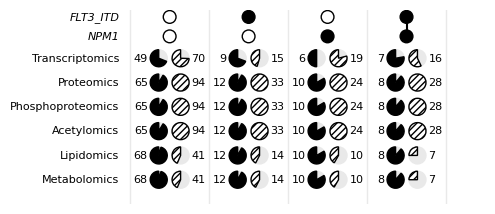

In [8]:
# --- setup ---

# figure and subpanels
fig, ax = plt.subplots(
    figsize=(5, 2.5),
)

# max font size 
rcParams["font.size"] = 8

# colors
c_white = "w"
c_black = "k"
c_border = c_black
c_grey = "#E9E9E9"

# misc parameters
w = 0.35            # bar width
lw = 1.             # line width for borders
r = 0.35           # circle radius
hatch = "/////"      # hatching for white bars
xfactor = 3.25
xoff = 0.45


# --- helper: make a pie ---

def _add_pie(x, y, has_block, total, black=True):
    theta_0 = 90
    proportion = has_block / total
    ax.add_patch(patches.Wedge(
        center=(x, y),
        r=r,
        theta1=theta_0,
        theta2=360 * proportion + theta_0,
        facecolor=c_black if black else c_white,
        edgecolor=c_border,
        hatch=None if black else hatch
    ))
    ax.text(
        x - xoff if black else x + xoff,
        y,
        str(has_block),
        ha="right" if black else "left",
        va="center" 
    )


# --- plot the data ---


# draw dividing lines
for x in np.arange(0, 5 * xfactor, xfactor):
    ax.axvline(
        x + xfactor / 2,
        lw=lw,
        c=c_grey
    )

# plot the field of empty circles
for x in np.arange(xfactor, 5 * xfactor, xfactor):
    for y in range(1, 7):
        for _x in [x - xoff, x + xoff]:
            ax.add_patch(patches.Circle(
                xy=(
                    _x, 
                    y
                ),
                radius=r,
                edgecolor=c_grey,
                lw=lw,
                facecolor=c_grey
            ))

# add block labels
block_to_y = {
    "Transcriptomics": 6,
    "Proteomics": 5,
    "Phosphoproteomics": 4,
    "Acetylomics": 3,
    "Lipidomics": 2,
    "Metabolomics": 1,
}
for blk, y in block_to_y.items():
    ax.text(
        xfactor / 2 - xoff,
        y,
        blk,
        ha="right",
        va="center"
    )

# add pies
mut_to_x = {
    "WT": xfactor,
    "FLT3-ITD": 2 * xfactor,
    "NPM1": 3 * xfactor,
    "NPM1xFLT3-ITD": 4 * xfactor
}
for (black, mut, block), (has_block, total) in omics_counts.items():
    if has_block > 0:
        _add_pie(
            mut_to_x[mut] - xoff if black else mut_to_x[mut] + xoff,
            block_to_y[block],
            has_block,
            total, 
            black=black
        )

# add the mutation indicator circles
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.plot(
    [xfactor * 4, xfactor * 4], 
    [6.9, 7.7], 
    "k-", 
    lw=1.5,
    zorder=-1
)
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.text(
    xfactor / 2 - xoff,
    7.7,
    "FLT3_ITD",
    ha="right",
    va="center",
    fontstyle="italic"
)
ax.text(
    xfactor / 2 - xoff,
    6.9,
    "NPM1",
    ha="right",
    va="center",
    fontstyle="italic"
)

# --- customization ---

ax.set_xlim((0, 5 * xfactor))
ax.set_ylim((0, 8))
ax.set_aspect("equal")
ax.set_axis_off()


# --- finish ---
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "mutations_omics_coverage_sample_counts.png"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

## Create Subsets

### Utility function for selecting subsets and applying transformations/normalizations
- filter columns to only include the selected samples for the subset (with two sample groups)
- filter rows to remove those that do not have at least 5 non-null values in WT and mutant groups
- apply row-wise z-score normalization across subset samples that are not null
    - require at least 5 samples within WT and mutant groups to z-score normalize

In [9]:
def select_subset(
    combined: pl.DataFrame,
    wt_cols: List[str],
    mut_cols: List[str]
) -> pl.DataFrame :
    """
    Select a subset of the combined -omics data DataFrame that contains a specified
    set of samples belonging to WT/mutant groups. 
    Filters rows with fewer than 5 
    Applies a row-wise z-score normalization to the full table 
    using non-null values from WT and mutant sample groups (no imputation).
    Returns the processed DataFrame with the selected subset.
    """
    return (
        combined
        .select(
            "Block",
            "Feature",
            *wt_cols,
            *mut_cols
        )
        .filter(
            (pl.sum_horizontal(~pl.col(wt_cols).is_null()) >= 5)
            & (pl.sum_horizontal(~pl.col(mut_cols).is_null()) >= 5)
        )
        .select(
            "Block",
            "Feature",
            (
                # pack the raw values into a list column
                pl.concat_list(
                    pl.col(wt_cols + mut_cols)
                )
                # compute row-wise z-scores
                .map_elements(
                    lambda x: stats.zscore(x, nan_policy="omit"), 
                    return_dtype=pl.List(pl.Float64)
                )
                # convert list to struct 
                .list.to_struct(
                    fields=wt_cols + mut_cols
                )
                .alias("packed")
            )
        )
        # unpack struct with z-scores back to sample columns
        .unnest("packed")
        # z-score makes NaNs out of null values, change them back
        .fill_nan(None)
    )

### Utility function to plot feature counts from the -omics data blocks before/after subsetting

In [10]:
def plot_filtered_feature_counts(
    combined: pl.DataFrame, 
    subset: pl.DataFrame, 
    figname=None
) :

    def _hex_to_rgba(hex: str, alpha: float) -> str : 
        """ add some transparency to rgb hex code and format it how plotly likes it """
        # assume the hex string starts with #
        ir = int(hex[1:3], 16)
        ig = int(hex[3:5], 16)
        ib = int(hex[5:7], 16)
        return f"rgba({ir}, {ig}, {ib}, {alpha})"

    # feature counts 
    counts = (
        combined
        .group_by("Block").len()
        .rename({"len": "pre"})
        .join(
            (
                subset
                .group_by("Block").len()
                .rename({"len": "post"})
            ), 
            how="left", 
            on="Block"
        )
        .fill_null(0)
        .sort("pre", descending=True)
    )

    # node: 
    #   key: {
    #       "index": index, 
    #       "color": color, 
    #       "label": label
    #       "count": count 
    #       "filtered": label <- for source nodes only
    # }
    node_data = {}

    # construct the node data from feature counts pre- and post-subsetting
    i = 0
    filtered = 0
    for block, pre, post in counts.iter_rows() :
        # add the node for pre-subsetting feature count
        node_data[f"{block}_0"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"{block} ({pre})",
            "count": pre,
            "filtered": pre - post
        }
        filtered += pre - post
        i += 1
        # add the node for post-subsetting feature count
        node_data[f"{block}_1"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"({post}) {block}",
            "count": post
        }
        i += 1

    # add a catch-all node for features that were filtered out
    node_data["Filtered"] = {
        "index": i,
        "color": COLORS["Filtered"],
        "label": f"({filtered}) Filtered",
        "count": filtered
    }

    # construct the link data from the node data
    link_data = {"source": [], "target": [], "value": [], "color": []}
    for block, pre, post in counts.iter_rows():
        # if features for a given block remained after subsetting, add a link
        if post > 0:
            link_data["source"].append(node_data[f"{block}_0"]["index"])
            link_data["target"].append(node_data[f"{block}_1"]["index"])
            link_data["value"].append(node_data[f"{block}_1"]["count"])
            link_data["color"].append(_hex_to_rgba(node_data[f"{block}_0"]["color"], 0.25))
        # always add the link from the block to filtered node
        link_data["source"].append(node_data[f"{block}_0"]["index"])
        link_data["target"].append(node_data["Filtered"]["index"])
        link_data["value"].append(node_data[f"{block}_0"]["filtered"])
        link_data["color"].append(_hex_to_rgba(node_data["Filtered"]["color"], 0.25))

        fig = pgo.Figure(
        data=[
            pgo.Sankey(
                arrangement="freeform",
                node=dict(
                    pad=15,
                    thickness=20,
                    line=dict(color="black", width=0.75),
                    label=[v["label"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                    color=[v["color"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                ),
                link=link_data
            )
        ]
    )
    if figname is not None:
        fig.write_image(figname, width=600, height=350, scale=4)
    fig.show()

### Utility function to do all the steps for a defined mutation comparison

In [44]:
def select_plot_and_save_subset(
    combined: pl.DataFrame,
    subset_id: str,
    wt_cols: List[str],
    mut_cols: List[str]
) -> pl.DataFrame :
    print(f"{mut_cols=}")
    
    # save the sample columns and upload to synapse
    wt_cols_f = os.path.join(CACHE_DIR, f"{subset_id}_wt-cols.txt")
    with open(wt_cols_f, "w") as out:
        out.write("\n".join(wt_cols))
    SYN.store(sceFile(path=wt_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["wt"]))
    
    mut_cols_f = os.path.join(CACHE_DIR, f"{subset_id}_mut-cols.txt")
    with open(mut_cols_f, "w") as out:
        out.write("\n".join(mut_cols))
    SYN.store(sceFile(path=mut_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["mut"]))

    # subset the omics data
    subset = select_subset(combined, wt_cols, mut_cols)

    # save the subset to file (arrow and CSV)
    arrow_f = os.path.join(CACHE_DIR, f"{subset_id}.arrow")
    subset.write_ipc(arrow_f)
    SYN.store(sceFile(path=arrow_f, id=SUBSET_DATA_SYN_IDS[subset_id]["arrow"]))
    
    csv_f = os.path.join(CACHE_DIR, f"{subset_id}.csv")
    subset.write_csv(csv_f)
    SYN.store(sceFile(path=csv_f, id=SUBSET_DATA_SYN_IDS[subset_id]["csv"]))

    # plot feature counts before/after subsetting
    plot_filtered_feature_counts(
        combined,
        subset,
        figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_NPM1-WT.png")
    )
    return subset

## Create all of the comparison subsets

In [45]:
# key: subset_id
# value: subset
subsets = {}

# run comparisons separately for black and white patient populations
for pop in ["Black", "White"]:

    # WT
    wt_cols = meta.filter(
        (pl.col("Race") == pop)
        & ~pl.col("NPM1")
        & ~pl.col("FLT3_ITD")
    )["Sample"].to_list()
    print("=" * 20 + f"{pop} patient population" + "=" * 20)
    print(f"{wt_cols=}")

    # NPM1 and FLT3-ITD single mutants
    for g in ["NPM1", "FLT3_ITD"]:
        print("=" * 20 + f"{pop} patient population: {g} vs. WT" + "=" * 20)
        not_g = {"NPM1": "FLT3_ITD", "FLT3_ITD": "NPM1"}[g]
        mut_cols = meta.filter(
            (pl.col("Race") == pop)
            & pl.col(g)
            & ~pl.col(not_g)
        )["Sample"].to_list()
        # annoying, I know. I was inconsistent with - vs. _ for FLT3-ITD at 
        # one point now I can't be bothered to fix it
        subset_id = f"{pop[0]}_{g.replace("_", "-")}-WT"
        subsets[subset_id] = select_plot_and_save_subset(
            combined, 
            subset_id,
            wt_cols, 
            mut_cols
        )

    # double mutant
    print("=" * 20 + f"{pop} patient population: double mutant vs. WT" + "=" * 20)
    mut_cols = meta.filter(
        (pl.col("Race") == pop)
        & pl.col("NPM1")
        & pl.col("FLT3_ITD")
    )["Sample"].to_list()
    subset_id = f"{pop[0]}_FLT3-ITDxNPM1-WT"
    subsets[subset_id] = select_plot_and_save_subset(
        combined, 
        subset_id,
        wt_cols, 
        mut_cols
    )

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:13: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=wt_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["wt"]))



====================Black patient population====================
wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
=======

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:18: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=mut_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["mut"]))

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:26: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=arrow_f, id=SUBSET_DATA_SYN_IDS[subset_id]["arrow"]))

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:30: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=csv_f, id=SUBSET

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:13: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=wt_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["wt"]))



====================Black patient population: FLT3_ITD vs. WT====================
mut_cols=['16-00088', 'C-09-0143', 'C-08-2480', 'C-12-0858', 'C-09-2182', 'C-10-3265', '93-C-154', 'C-00-0561', 'C-05-0927', 'C-99-0027', 'C-04-1161', 'C-09-1033', 'C-99-1700']


...

====================White patient population: FLT3_ITD vs. WT====================
mut_cols=['11-00261', '12-00032', '11-00382', '11-00388', '11-00416', '11-00465', '12-00145', '12-00196', '12-00294', '12-00383', '13-00075', '13-00581', '13-00584', '17-00641', '14-00817', '15-00571', '15-00764', '15-00811', '16-00120', '16-00271', '16-00498', '16-00731', '16-01098', '16-01185', '17-00028', '17-00115', '17-00123', '17-00634', '18-00007', '13-00016', '12-00268', '16-00120-Bridge', '16-00731-Bridge']


Uploading to Synapse storage: 100%|█████████████████████████| 894/894 [00:00<00:00, 2.50kB/s, W_FLT3-ITD-WT_wt-cols.txt]
[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:18: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=mut_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["mut"]))

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:26: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=arrow_f, id=SUBSET_DATA_SYN_IDS[subset_id]["arrow"]))

Uploading to Synapse storage: 100%|███████████████████████████| 42.6M/42.6M [00:24<00:00, 1.77MB/s, W_FLT3-ITD-WT.arrow]
[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipyker

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:13: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=wt_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["wt"]))



====================White patient population: double mutant vs. WT====================
mut_cols=['11-00503', '11-00475', '11-00376', '11-00378', '11-00466', '12-00123', '13-00262', '13-00450', '14-00495', '15-00872', '15-00983', '16-00041', '16-00109', '16-00289', '16-00292', '16-00459', '16-00836', '16-00844', '17-00963', '16-01225', '17-00025', '17-00551', '17-00613', '17-00775', '17-00849', '17-00915', '19-00154', '17-00025-Bridge']


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:18: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=mut_cols_f, id=SUBSET_DATA_SYN_IDS[subset_id]["mut"]))

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:26: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synapseclient.operations import store` instead.) -- Deprecated since version 4.11.0.
  SYN.store(sceFile(path=arrow_f, id=SUBSET_DATA_SYN_IDS[subset_id]["arrow"]))

Uploading to Synapse storage: 100%|██████████████████████| 41.0M/41.0M [00:18<00:00, 2.19MB/s, W_FLT3-ITDxNPM1-WT.arrow]
[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_83132/4075614485.py:30: DeprecationWarning: Call to deprecated method store. (To be removed in 5.0.0. Use `from synap